<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202502_Doe_DCA_Form1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejemplo 1. Diseños Completos Aleatorizados (DCA) en Python y R**
# **Escribe el Nombre del Curso: Diseño de Experimentos**
## **Escribe tu nombre completo: Julio Hurtado**
> Email: **juliohurtado210307@gmail.com**


# **Librerias para Trabar en R**

In [101]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [102]:
# @title **Librerias para Trabar en Colab**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats

<a name="inicio"></a>


## **1.** [Problema a Resolver - DCA](#T1)
## **2.** [Nombre de Diseño de Experimento e Hipotesis](#T2)

## **3.** [BoxPlot para el DCA](#T3)

## **4.** [Análisis de Varianza (ANOVA)](#T4)

## **5.** [Resumen del Análisis de Varianza](#T5)

## **6.** [Comparaciones Múltiples - HSD](#T6)

## **7.** [Comparaciones Múltiples - Prueba LSD ($\alpha=0.05$)](#T7)


## **8.** [Supuesto del Modelo - Normalidad](#T8)

## **9.** [Homocedasticidad](#T9)


## **10.** [Independencia - _`durbin_watson`  y `Ljung-Box`_](#T10)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Problema a Resolver - DCA**
+ **Problema 1: Una compañía compra materia prima a tres proveedores. La pureza de esta materia prima es un importante en la calidad del producto terminado. El departamento de calidad quiere determinar si existen diferencias en la pureza de la materia prima debido al proveedor. Se selecciona al azar 4 muestras de materia prima de cada proveedor de la última compra realizada en el mes, los resultados fueron los siguientes.**
| Proveedor A | Proveedor B | Proveedor C |
|---|---|---|
| 94 | 88 | 95 |
| 95 | 92 | 96 |
| 93 | 86 | 96 |
| 96 | 87 | 92 |

In [103]:
# @title **A. DataFrame en Python**
data = {'Proveedor': ['A'] * 4 + ['B'] * 4 + ['C'] * 4,
        'Pureza': [94, 95, 93, 96,
                     88, 92, 86, 87,
                     95, 96, 96, 92]}

df = pd.DataFrame(data)
display(df)

,Proveedor,Pureza
0,A,94
1,A,95
2,A,93
3,A,96
4,B,88
5,B,92
6,B,86
7,B,87
8,C,95
9,C,96


In [104]:
%%R
# @title **B. DataFrame en R**
# Create the data as vectors
proveedor <- c(rep("A", 4), rep("B", 4), rep("C", 4))
pureza <- c(94, 95, 93, 96,
            88, 92, 86, 87,
            95, 96, 96, 92)

# Create the DataFrame
df_r <- data.frame(Proveedor = proveedor, Pureza = pureza)

# Display the DataFrame
print(df_r)

   Proveedor Pureza
1          A     94
2          A     95
3          A     93
4          A     96
5          B     88
6          B     92
7          B     86
8          B     87
9          C     95
10         C     96
11         C     96
12         C     92


[⬆️ Volver al inicio](#inicio)

In [105]:
display(df)

,Proveedor,Pureza
0,A,94
1,A,95
2,A,93
3,A,96
4,B,88
5,B,92
6,B,86
7,B,87
8,C,95
9,C,96


<a name="T2"></a>
## **2. Visualizando el DataFrame**


# **Nombre de Diseño de Experimento**
+ **Diseño Completamente Aleatorizado**
* **Modelo**
$$Y_{ij}=\mu+\tau_i + ε_{ij}$$

# **Hipotesis del DCA**
+ **Hipotesis Nula**: _La Pureza de la Materia prima no depende del tipo de proveedor_
$$H_0: μ_A=μ_B=μ_C=μ$$

+ **Hipotesis Alternativa**: _La Pureza de la Materia prima difiere en almenos un par de proveedores_
$$H_1: μ_i\neq μ_j$$

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. BoxPlot para el DCA**


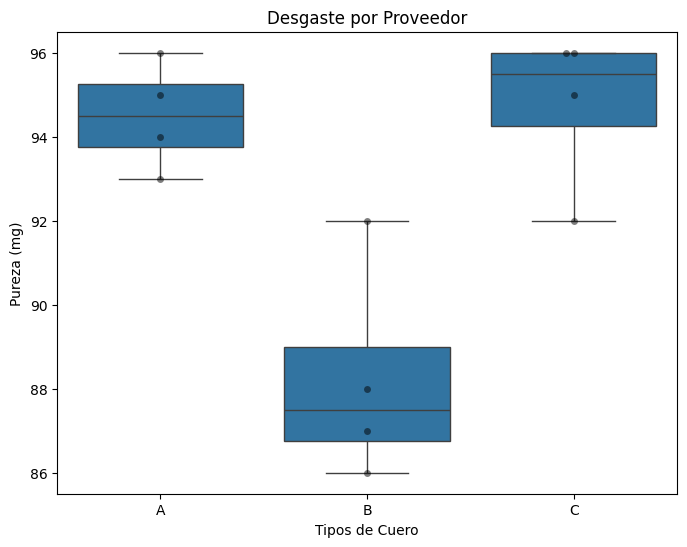

In [106]:
# @title **A. BoxPlot para el DCA en Python**
plt.figure(figsize=(8, 6))
sns.boxplot(x="Proveedor", y="Pureza", data=df)
sns.swarmplot(x="Proveedor", y="Pureza", data=df, color='black', alpha=0.5)
plt.title('Desgaste por Proveedor')
plt.xlabel('Tipos de Cuero')
plt.ylabel('Pureza (mg)')
plt.show()

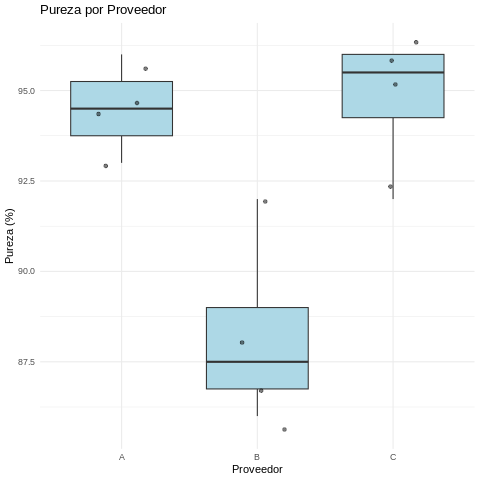

In [107]:
%%R
# @title **C. BoxPlot para el DCA en R (Pureza)**
library(ggplot2)

# Create the boxplot with swarmplot overlay
ggplot(df_r, aes(x = Proveedor, y = Pureza)) +
  geom_boxplot(fill = "lightblue") + # Add boxplot with fill color
  geom_jitter(width = 0.2, color = "black", alpha = 0.5) + # Add swarmplot (jittered points)
  labs(title = "Pureza por Proveedor",
       x = "Proveedor",
       y = "Pureza (%)") +
  theme_minimal() # Use a minimal theme

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Análisis de Varianza (ANOVA)**


In [108]:
# @title **A. Análisis de Varianza (ANOVA) en Python**
modelo_desgaste = ols("Pureza ~ Q('Proveedor')", data=df).fit()
anova_desgaste = sm.stats.anova_lm(modelo_desgaste, typ=1)
print(anova_desgaste)

                 df  sum_sq    mean_sq          F    PR(>F)
Q('Proveedor')  2.0   108.5  54.250000  13.376712  0.002014
Residual        9.0    36.5   4.055556        NaN       NaN


In [109]:
%%R
# @title **Análisis de Varianza (ANOVA) en R**
# Perform ANOVA
anova_result <- aov(Pureza ~ Proveedor, data = df_r)

# Print ANOVA summary
summary(anova_result)

            Df Sum Sq Mean Sq F value  Pr(>F)   
Proveedor    2  108.5   54.25   13.38 0.00201 **
Residuals    9   36.5    4.06                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Resumen del Análisis de Varianza**




In [110]:
# @title **Resumen del Análisis de Varianza**

print(modelo_desgaste.summary())

                            OLS Regression Results                            
Dep. Variable:                 Pureza   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     13.38
Date:                Sat, 06 Sep 2025   Prob (F-statistic):            0.00201
Time:                        21:10:43   Log-Likelihood:                -23.702
No. Observations:                  12   AIC:                             53.40
Df Residuals:                       9   BIC:                             54.86
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              94.5000    

In [111]:
%%R
# @title **Resumen del Análisis de Varianza en R**

# Print ANOVA summary
summary(anova_result)

            Df Sum Sq Mean Sq F value  Pr(>F)   
Proveedor    2  108.5   54.25   13.38 0.00201 **
Residuals    9   36.5    4.06                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Comparaciones Múltiples - HSD**


In [112]:
# @title **A. Comparaciones Múltiples - Desgaste $\alpha=0.05$**

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df['Pureza'], groups=df['Proveedor'], alpha=0.05)

# Print the results
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B    -6.25 0.0045 -10.2258 -2.2742   True
     A      C     0.25 0.9832  -3.7258  4.2258  False
     B      C      6.5 0.0035   2.5242 10.4758   True
-----------------------------------------------------


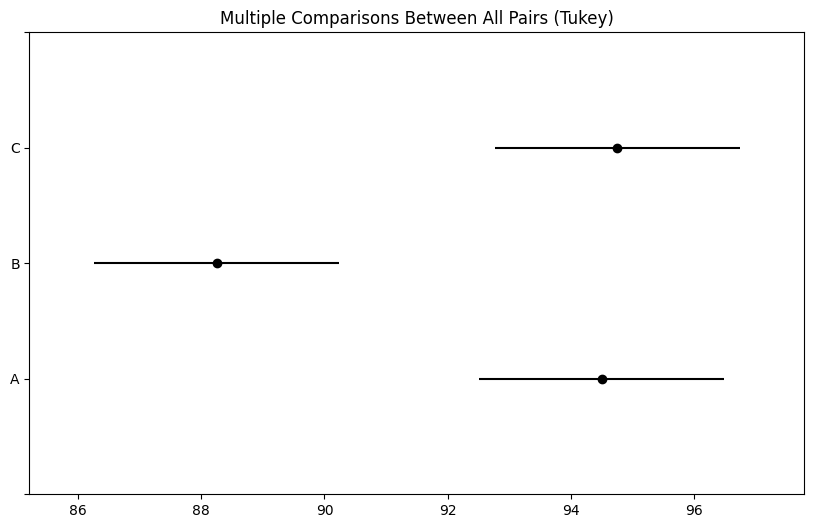

In [113]:
# @title **B. Gráfico de Comparaciones Múltiples Tukey**
import matplotlib.pyplot as plt

# Plot the Tukey HSD results
tukey_result.plot_simultaneous()
plt.show()

In [114]:
# @title **C. Comparaciones Múltiples - Pureza $\alpha=0.001$**

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result2 = pairwise_tukeyhsd(endog=df['Pureza'], groups=df['Proveedor'], alpha=0.001)

# Print the results
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B    -6.25 0.0045 -10.2258 -2.2742   True
     A      C     0.25 0.9832  -3.7258  4.2258  False
     B      C      6.5 0.0035   2.5242 10.4758   True
-----------------------------------------------------


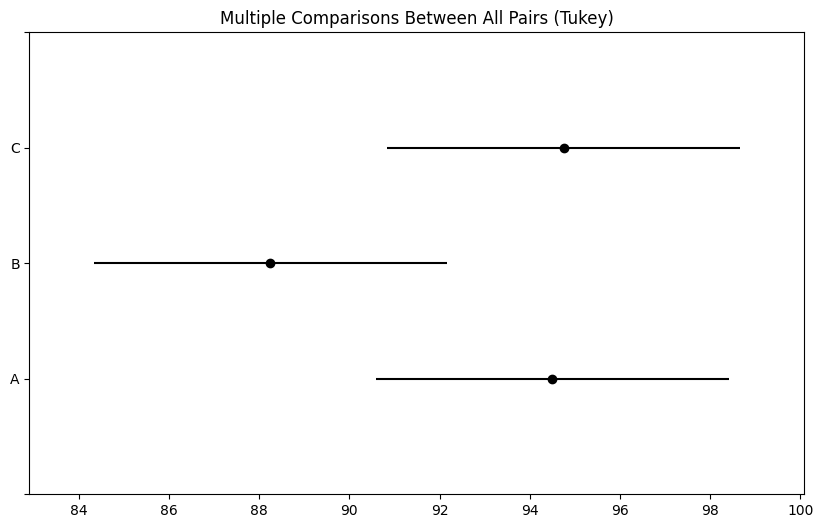

In [115]:
# @title **D. Gráfico de Comparaciones Múltiples Tukey**
import matplotlib.pyplot as plt

# Plot the Tukey HSD results
tukey_result2.plot_simultaneous()
plt.show()

In [116]:
%%R
# @title **E. Comparaciones Múltiples - Desgaste en R**
# Perform Tukey's HSD post-hoc test
tukey_result_r <- TukeyHSD(anova_result)

# Print the results
print(tukey_result_r)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Pureza ~ Proveedor, data = df_r)

$Proveedor
     diff        lwr       upr     p adj
B-A -6.25 -10.225818 -2.274182 0.0044656
C-A  0.25  -3.725818  4.225818 0.9831833
C-B  6.50   2.524182 10.475818 0.0034816



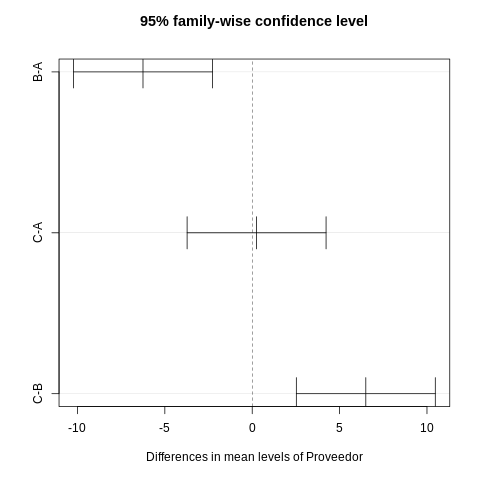

In [117]:
%%R
# @title **F. HSD de Tukey Grafico para la diferencia de Medias en R**
# Plot the Tukey HSD results
plot(tukey_result_r)

[⬆️ Volver al inicio](#inicio)

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Comparaciones Múltiples - Prueba LSD ($\alpha=0.05$)**

In [118]:
# @title **A. Comparaciones Múltiples - Prueba LSD ($\alpha=0.05$)**

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Fisher's LSD post-hoc test
# NOTA: pairwise_tukeyhsd es específicamente para Tukey HSD, no para LSD
# Para LSD necesitarías usar otra función o implementarlo manualmente

# Opción 1: Si quieres usar Tukey HSD (método recomendado para comparaciones múltiples)
tukey_result = pairwise_tukeyhsd(endog=df['Pureza'], groups=df['Proveedor'], alpha=0.05)
print("Prueba de Tukey HSD:")
print(tukey_result)

# Opción 2: Para LSD de Fisher, necesitarías implementarlo manualmente o usar:
from statsmodels.stats.libqsturng import psturng
import numpy as np
from scipy import stats

# Implementación básica de LSD
print("\n" + "="*50)
print("Prueba LSD de Fisher (implementación básica):")

# Calcular medias por grupo
group_means = df.groupby('Proveedor')['Pureza'].mean()
group_counts = df.groupby('Proveedor')['Pureza'].count()
groups = group_means.index.tolist()

# Calcular MSE (Mean Square Error) del ANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols('Pureza ~ C(Proveedor)', data=df).fit()
anova_table = anova_lm(model)
mse = anova_table['mean_sq']['Residual']

# Grados de libertad del error
df_error = anova_table['df']['Residual']

# Calcular LSD para cada par de grupos
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        grupo1, grupo2 = groups[i], groups[j]
        mean_diff = abs(group_means[grupo1] - group_means[grupo2])

        # Calcular el error estándar de la diferencia
        n1, n2 = group_counts[grupo1], group_counts[grupo2]
        sed = np.sqrt(mse * (1/n1 + 1/n2))

        # Valor crítico t
        t_critical = stats.t.ppf(1 - 0.05/2, df_error)
        lsd = t_critical * sed

        # Determinar significancia
        significativo = "SÍ" if mean_diff > lsd else "NO"

        print(f"{grupo1} vs {grupo2}: Diferencia = {mean_diff:.4f}, LSD = {lsd:.4f} → Significativo: {significativo}")

Prueba de Tukey HSD:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B    -6.25 0.0045 -10.2258 -2.2742   True
     A      C     0.25 0.9832  -3.7258  4.2258  False
     B      C      6.5 0.0035   2.5242 10.4758   True
-----------------------------------------------------

Prueba LSD de Fisher (implementación básica):
A vs B: Diferencia = 6.2500, LSD = 3.2213 → Significativo: SÍ
A vs C: Diferencia = 0.2500, LSD = 3.2213 → Significativo: NO
B vs C: Diferencia = 6.5000, LSD = 3.2213 → Significativo: SÍ


In [119]:
%%R
# @title **B. Comparaciones Múltiples - Prueba LSD ($\alpha=0.05$) en R**
# Install and load the agricolae package if not already installed
if (!requireNamespace("agricolae", quietly = TRUE)) {
  install.packages("agricolae")
}
library(agricolae)

# Perform LSD test
LSD.test(anova_result,"Proveedor",console=TRUE)


Study: anova_result ~ "Proveedor"

LSD t Test for Pureza 

Mean Square Error:  4.055556 

Proveedor,  means and individual ( 95 %) CI

  Pureza      std r      se      LCL      UCL Min Max   Q25  Q50   Q75
A  94.50 1.290994 4 1.00692 92.22219 96.77781  93  96 93.75 94.5 95.25
B  88.25 2.629956 4 1.00692 85.97219 90.52781  86  92 86.75 87.5 89.00
C  94.75 1.892969 4 1.00692 92.47219 97.02781  92  96 94.25 95.5 96.00

Alpha: 0.05 ; DF Error: 9
Critical Value of t: 2.262157 

least Significant Difference: 3.221313 

Treatments with the same letter are not significantly different.

  Pureza groups
C  94.75      a
A  94.50      a
B  88.25      b


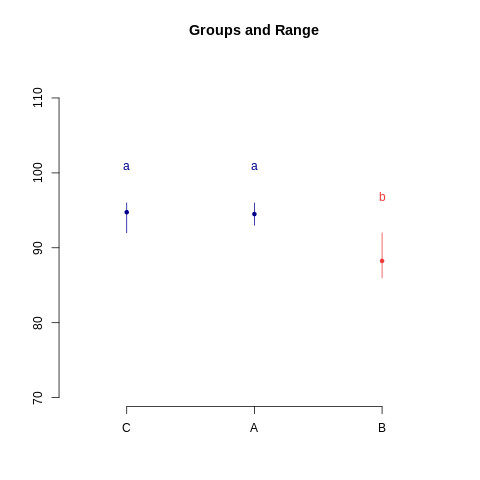

In [120]:
%%R
# @title **C. Gráfico de Comparaciones Múltiples LSD en R**
# Plot the LSD test results
plot(LSD.test(anova_result,"Proveedor",console=FALSE))

In [121]:
%%R
# @title **D. Comparaciones Múltiples - Prueba LSD ($\alpha=0.01$) en R**
# Install and load the agricolae package if not already installed (already done above, but included for completeness)
if (!requireNamespace("agricolae", quietly = TRUE)) {
  install.packages("agricolae")
}
library(agricolae)

# Perform LSD test with alpha = 0.01
LSD.test(anova_result,"Proveedor",console=TRUE, alpha=0.01)


Study: anova_result ~ "Proveedor"

LSD t Test for Pureza 

Mean Square Error:  4.055556 

Proveedor,  means and individual ( 99 %) CI

  Pureza      std r      se      LCL      UCL Min Max   Q25  Q50   Q75
A  94.50 1.290994 4 1.00692 91.22767 97.77233  93  96 93.75 94.5 95.25
B  88.25 2.629956 4 1.00692 84.97767 91.52233  86  92 86.75 87.5 89.00
C  94.75 1.892969 4 1.00692 91.47767 98.02233  92  96 94.25 95.5 96.00

Alpha: 0.01 ; DF Error: 9
Critical Value of t: 3.249836 

least Significant Difference: 4.627768 

Treatments with the same letter are not significantly different.

  Pureza groups
C  94.75      a
A  94.50      a
B  88.25      b


[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Supuesto del Modelo - Normalidad**


In [122]:
# @title **A. Normalidad Prueba de  Shapiro Wilks**
w, pvalue = stats.shapiro(modelo_desgaste.resid)


print(f"W statistic: {w:.4f}")
print(f"p-value: {pvalue:.4f}")

W statistic: 0.9716
p-value: 0.9271


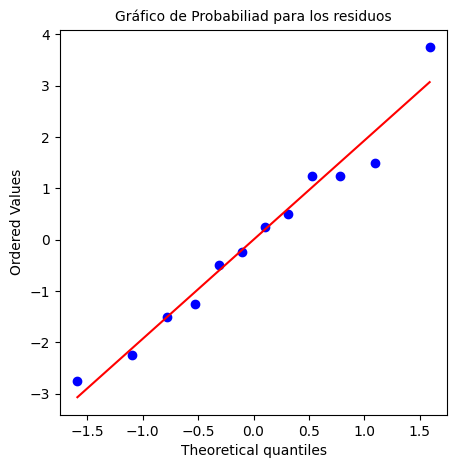

In [123]:
# @title **B. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
fig = plt.figure(figsize= (5, 5))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(modelo_desgaste.resid, plot= plt, rvalue= False)
ax.set_title("Gráfico de Probabiliad para los residuos", fontsize= 10)
ax.set

plt.show()

In [124]:
# @title **C. Residuos del Modelo**
modelo_desgaste.resid.describe()

,0
count,1.200000e+01
mean,-4.736952e-15
std,1.821588e+00
min,-2.750000e+00
25%,-1.312500e+00
50%,0.000000e+00
75%,1.250000e+00
max,3.750000e+00


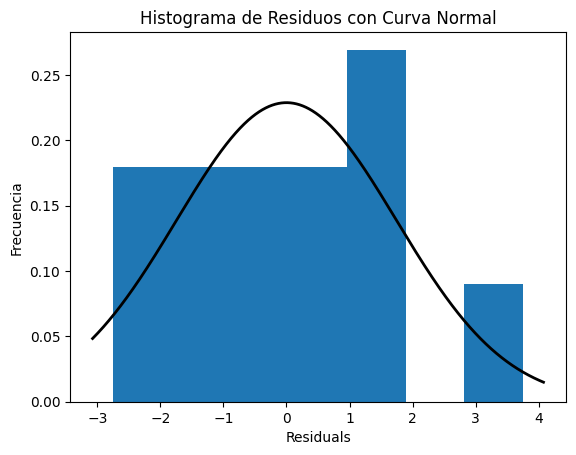

In [125]:
# @title **D. Histograma de Residuos con curva normal teórica**
plt.hist(modelo_desgaste.resid, bins=7, histtype='bar', ec='k', density=True)

# Calculate mean and standard deviation for the theoretical normal curve
mu, sigma = stats.norm.fit(modelo_desgaste.resid)

# Create the theoretical normal curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 10000)
p = stats.norm.pdf(x, mu, sigma)

# Plot the theoretical normal curve
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel("Residuals")
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos con Curva Normal')
plt.show()

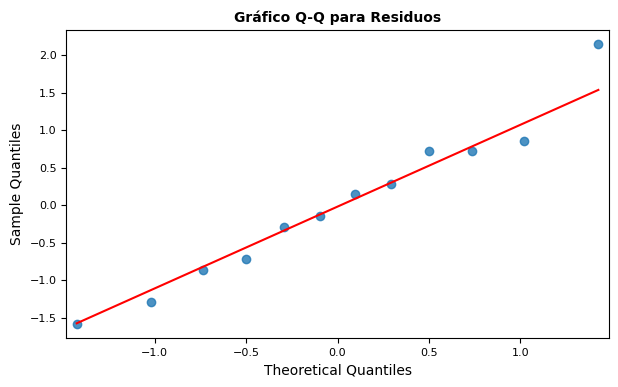

In [126]:
# @title **E. Gráfico Q-Q**
# ==============================================================================
fig, ax = plt.subplots(figsize=(7,4))
sm.qqplot(
    modelo_desgaste.resid, # Pass the residuals here
    fit   = True,
    line  = 'q',
    alpha = 0.8,
    lw    = 5,
    ax    = ax
)
ax.set_title('Gráfico Q-Q para Residuos', fontsize = 10, # Changed title for clarity
             fontweight = "bold")
ax.tick_params(labelsize = 8)

plt.show() # Added to display the plot

[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Homocedasticidad**


In [127]:
# @title **A. Homocedasticidad de los residuos: Usando la prueba de Levene**
# The levene test requires separate arguments for each group's data.
# We can get the data for each provider by filtering the DataFrame.
provider_a_pureza = df['Pureza'][df['Proveedor'] == 'A']
provider_b_pureza = df['Pureza'][df['Proveedor'] == 'B']
provider_c_pureza = df['Pureza'][df['Proveedor'] == 'C']

L = stats.levene(provider_a_pureza,
                 provider_b_pureza,
                 provider_c_pureza)

print("Estadístico de Levene: ", np.round(L.statistic,4))
print("Valor p: ", np.round(L.pvalue,4))

Estadístico de Levene:  0.2838
Valor p:  0.7594


In [129]:
# @title **B. Homocedasticidad de los residuos: Usando la prueba de Levene**
tratamientos = df['Proveedor'].unique()
grupos = [df.loc[df['Proveedor'] == trt, 'Pureza'] for trt in sorted(tratamientos)]

resultado_levene = stats.levene(*grupos)

# Interpretación
print("="*60)
print("PRUEBA DE LEVENE PARA HOMOCEDASTICIDAD")
print("="*60)
print(f"Estadístico de Levene: {resultado_levene.statistic:.4f}")
print(f"Valor p: {resultado_levene.pvalue:.4f}")

if resultado_levene.pvalue > 0.05:
    print("✓ No se rechaza H0: Las varianzas son homogéneas (p > 0.05)")
else:
    print("✗ Se rechaza H0: Las varianzas NO son homogéneas (p ≤ 0.05)")
print("="*60)

PRUEBA DE LEVENE PARA HOMOCEDASTICIDAD
Estadístico de Levene: 0.2838
Valor p: 0.7594
✓ No se rechaza H0: Las varianzas son homogéneas (p > 0.05)


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. Independencia - _`durbin_watson`  y `Ljung-Box`_**

ANÁLISIS DE INDEPENDENCIA DE LOS RESIDUOS
Estadístico de Durbin-Watson: 2.4469
✓ No hay evidencia de autocorrelación (los residuos son independientes)
----------------------------------------


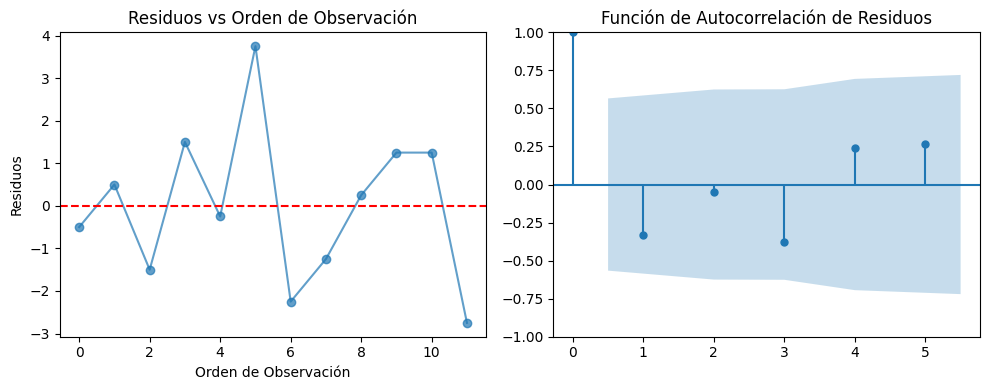


Prueba de Ljung-Box (lag 1): p-value = 0.1965
✓ No se rechaza H0: No hay autocorrelación (residuos independientes)


In [131]:
# @title **B. Supuesto de Independencia de los residuos**

print("="*60)
print("ANÁLISIS DE INDEPENDENCIA DE LOS RESIDUOS")
print("="*60)

# 1. Prueba de Durbin-Watson (para autocorrelación)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox # Import acorr_ljungbox

# Use the residuals from the previously fitted model
residuos = modelo_desgaste.resid

# Prueba de Durbin-Watson
dw_test = durbin_watson(residuos)
print(f"Estadístico de Durbin-Watson: {dw_test:.4f}")

# Interpretación
if 1.5 < dw_test < 2.5:
    print("✓ No hay evidencia de autocorrelación (los residuos son independientes)")
elif dw_test <= 1.5:
    print("✗ Positiva autocorrelación detectada (los residuos no son independientes)")
else:
    print("✗ Negativa autocorrelación detectada (los residuos no son independientes)")

print("-"*40)

# 2. Gráfico de residuos vs orden de observación
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(residuos, 'o-', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Orden de Observación')
plt.xlabel('Orden de Observación')
plt.ylabel('Residuos')

# 3. Gráfico de autocorrelación
plt.subplot(1, 2, 2)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos, lags=min(10, len(residuos)//2 -1), alpha=0.05, ax=plt.gca()) # Adjusted lags
plt.title('Función de Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

# 4. Prueba de Ljung-Box (opcional)
# The lags parameter for Ljung-Box test should be less than the number of observations.
# A common rule of thumb is lags <= n/4, where n is the number of observations.
# Here, n=12, so lags should be <= 3.
# Let's use lags=[1] as an example, or [1, 2, 3]
try:
    lb_test = acorr_ljungbox(residuos, lags=[1], return_df=True)
    print(f"\nPrueba de Ljung-Box (lag 1): p-value = {lb_test['lb_pvalue'].values[0]:.4f}")

    if lb_test['lb_pvalue'].values[0] > 0.05:
        print("✓ No se rechaza H0: No hay autocorrelación (residuos independientes)")
    else:
        print("✗ Se rechaza H0: Hay autocorrelación (residuos no independientes)")
except ValueError as e:
    print(f"\nCould not perform Ljung-Box test: {e}. This can happen with very small sample sizes.")


print("="*60)

[⬆️ Volver al inicio](#inicio)